# TP3 - Deep Learning: MLP do zero no Adult Income

Este notebook implementa uma rede neural artificial **do zero** para o tema **Adult Income (UCI)**, seguindo o enunciado do TP3 e o guia exploratório do projeto.

Objetivos cobertos:

- Forward pass, backpropagation e atualização por mini-batch gradient descent.
- ReLU nas camadas escondidas, Softmax na saída e Cross-Entropy como função de custo.
- Curvas de loss e acurácia em treino/teste.
- Experimentos com taxa de aprendizado, tamanho do batch e arquitetura.
- Análise de viés para atributos sensíveis (`sex` e `race`).
- Mitigação simples por reponderação (`reweighing`).
- Interpretabilidade por permutation importance e gradientes de entrada.

Fonte do dataset: UCI Machine Learning Repository, Adult Dataset, https://archive.ics.uci.edu/ml/datasets/Adult.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
rng = np.random.default_rng(SEED)

# Mantenha False para máxima compatibilidade na entrega. Se tiver CuPy instalado e CUDA,
# altere para True para treinar na GPU sem mudar a implementação da rede.
USE_CUPY = False

if USE_CUPY:
    try:
        import cupy as cp
        xp = cp
        BACKEND = 'cupy'
    except Exception as exc:
        print(f'CuPy indisponível ({exc}). Usando NumPy.')
        xp = np
        BACKEND = 'numpy'
else:
    xp = np
    BACKEND = 'numpy'

print(f'Backend numérico: {BACKEND}')

Backend numérico: numpy


## 1. Carregamento do dataset

O Adult Income possui a partição original de treino (`adult.data`) e teste (`adult.test`). O alvo é binário: `<=50K` ou `>50K`.

A limpeza abaixo remove espaços, normaliza o ponto final presente no arquivo de teste e preserva valores ausentes `?` como a categoria `Unknown`, em vez de descartar linhas.

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
DATA_DIR.mkdir(exist_ok=True)
print(f'Diretório de dados: {DATA_DIR}')

ADULT_URLS = {
    'adult.data': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    'adult.test': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test',
    'adult.names': 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names',
}

COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status',
    'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss',
    'hours_per_week', 'native_country', 'income'
]

NUMERIC_COLS = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
CATEGORICAL_COLS = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
TARGET_COL = 'income'


def download_adult_files():
    for filename, url in ADULT_URLS.items():
        dest = DATA_DIR / filename
        if not dest.exists():
            print(f'Baixando {filename}...')
            urlretrieve(url, dest)


def read_adult_file(path, is_test=False):
    df = pd.read_csv(
        path,
        names=COLUMNS,
        sep=',',
        skipinitialspace=True,
        skiprows=1 if is_test else 0,
        na_values=[],
        keep_default_na=False,
    )
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].astype(str).str.strip()
    df[TARGET_COL] = df[TARGET_COL].str.replace('.', '', regex=False)
    return df


def clean_adult(df):
    cleaned = df.copy()
    for col in CATEGORICAL_COLS:
        cleaned[col] = cleaned[col].replace('?', 'Unknown')
    for col in NUMERIC_COLS:
        cleaned[col] = pd.to_numeric(cleaned[col], errors='coerce')
    return cleaned


download_adult_files()
train_raw = read_adult_file(DATA_DIR / 'adult.data')
test_raw = read_adult_file(DATA_DIR / 'adult.test', is_test=True)

train_df = clean_adult(train_raw)
test_df = clean_adult(test_raw)

print('Treino:', train_df.shape)
print('Teste :', test_df.shape)
train_df.head()

Diretório de dados: /home/guilherme/Documentos/unicamp/mc906/at3/Deep-Learning-Adult-Income/data
Treino: (32561, 15)
Teste : (16281, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. EDA rápida

Aqui observamos distribuição de classes, valores ausentes mascarados e disparidades iniciais por grupos sensíveis. Essa parte sustenta a discussão crítica do relatório.

Distribuição do alvo no treino


,n,%
income,,
<=50K,24720,75.92
>50K,7841,24.08


Valores Unknown por coluna categórica


,unknown_count
occupation,1843
workclass,1836
native_country,583
marital_status,0
relationship,0
race,0
sex,0


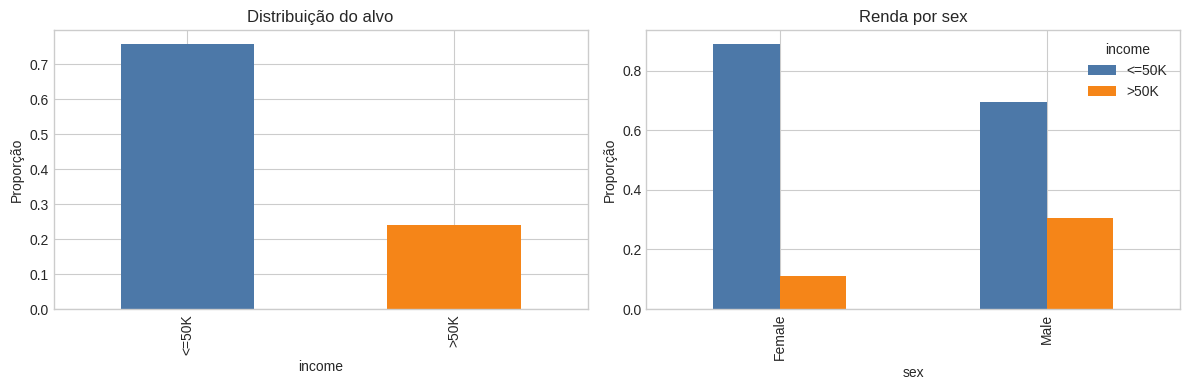

In [3]:
def class_table(df, col=TARGET_COL):
    counts = df[col].value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(2)
    return pd.DataFrame({'n': counts, '%': pct})

print('Distribuição do alvo no treino')
display(class_table(train_df))

print('Valores Unknown por coluna categórica')
unknown_counts = (train_df[CATEGORICAL_COLS] == 'Unknown').sum().sort_values(ascending=False)
display(unknown_counts.to_frame('unknown_count'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df[TARGET_COL].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[0], color=['#4C78A8', '#F58518'])
axes[0].set_title('Distribuição do alvo')
axes[0].set_ylabel('Proporção')

pd.crosstab(train_df['sex'], train_df[TARGET_COL], normalize='index').sort_index().plot(kind='bar', ax=axes[1], color=['#4C78A8', '#F58518'])
axes[1].set_title('Renda por sex')
axes[1].set_ylabel('Proporção')
axes[1].legend(title='income')
plt.tight_layout()
plt.show()

In [4]:
print('Taxa real de >50K por sex')
display(pd.crosstab(train_df['sex'], train_df[TARGET_COL], normalize='index')['>50K'].sort_values(ascending=False).to_frame('P(>50K)'))

print('Taxa real de >50K por race')
display(pd.crosstab(train_df['race'], train_df[TARGET_COL], normalize='index')['>50K'].sort_values(ascending=False).to_frame('P(>50K)'))

Taxa real de >50K por sex


,P(>50K)
sex,
Male,0.305737
Female,0.109461


Taxa real de >50K por race


,P(>50K)
race,
Asian-Pac-Islander,0.265640
White,0.255860
Black,0.123880
Amer-Indian-Eskimo,0.115756
Other,0.092251


## 3. Pré-processamento e engenharia de features

Aqui eu reduzo a explosão do one-hot encoding agrupando categorias com significado semelhante. A ideia é preservar o sinal útil para o Adult Income sem carregar dezenas de colunas quase redundantes.

Principais decisões:

- `marital_status` vira um indicador compacto: solteiro, casado, separado/divorciado ou viúvo.
- `workclass` é reduzida para trabalho privado, autônomo, governo, sem renda/atípico e desconhecido.
- `occupation` é agrupada em blocos mais amplos: escritório/tecnologia/vendas, serviços/manuais, profissional, agro, proteção/militar e desconhecido.
- `relationship` vira papéis familiares mais compactos.
- `race` permanece informativa, mas sem expansão desnecessária.
- `native_country` é agrupada por regiões amplas, com `US` separado e o restante consolidado.

Depois disso ainda aplico one-hot encoding, mas em um espaço bem menor do que o original.

In [5]:
class AdultPreprocessor:
    def __init__(self, numeric_cols, categorical_cols, drop_cols=None):
        self.numeric_cols = list(numeric_cols)
        self.categorical_cols = list(categorical_cols)
        self.drop_cols = set(drop_cols or [])
        self.numeric_cols = [c for c in self.numeric_cols if c not in self.drop_cols]
        self.categorical_cols = [c for c in self.categorical_cols if c not in self.drop_cols]
        self.means_ = None
        self.stds_ = None
        self.categories_ = {}
        self.feature_names_ = []
        self.feature_groups_ = {}
        self.category_summary_ = None

    def fit(self, df):
        self.means_ = df[self.numeric_cols].mean()
        self.stds_ = df[self.numeric_cols].std(ddof=0).replace(0, 1)
        self._build_categories(df)
        self._build_feature_metadata()
        return self

    def _build_categories(self, df):
        summary_rows = []
        self.categories_ = {}
        for col in self.categorical_cols:
            if col == 'workclass':
                self.categories_[col] = ['Private', 'Self-employed', 'Government', 'Without-pay/Never-worked', 'Unknown']
            elif col == 'marital_status':
                self.categories_[col] = ['Married', 'Single', 'Separated/Divorced', 'Widowed', 'Unknown']
            elif col == 'occupation':
                self.categories_[col] = ['Office/tech/sales', 'Manual/services', 'Professional', 'Agriculture', 'Protective/military', 'Unknown']
            elif col == 'relationship':
                self.categories_[col] = ['Spouse', 'Child', 'Not-in-family', 'Other-relative', 'Unknown']
            elif col == 'race':
                self.categories_[col] = ['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other/Unknown']
            elif col == 'sex':
                self.categories_[col] = ['Female', 'Male']
            elif col == 'native_country':
                self.categories_[col] = ['US', 'North America', 'Latin America', 'Europe', 'Asia-Pacific', 'Other/Unknown']
            else:
                cats = sorted(df[col].astype(str).unique().tolist())
                if 'Unknown' not in cats:
                    cats.append('Unknown')
                self.categories_[col] = cats

            summary_rows.append({
                'feature': col,
                'n_original_options': int(df[col].nunique(dropna=False)),
                'n_engineered_options': len(self.categories_[col]),
                'engineered_values': ', '.join(self.categories_[col]),
            })
        self.category_summary_ = pd.DataFrame(summary_rows)

    def _build_feature_metadata(self):
        names = []
        groups = {}
        idx = 0
        for col in self.numeric_cols:
            names.append(col)
            groups[col] = [idx]
            idx += 1
        for col in self.categorical_cols:
            indices = []
            for cat in self.categories_[col]:
                names.append(f'{col}={cat}')
                indices.append(idx)
                idx += 1
            groups[col] = indices
        self.feature_names_ = names
        self.feature_groups_ = groups

    def _map_categorical_value(self, col, value):
        value = str(value).strip()
        if col == 'workclass':
            if value == 'Private':
                return 'Private'
            if value in {'Self-emp-not-inc', 'Self-emp-inc'}:
                return 'Self-employed'
            if value in {'Federal-gov', 'Local-gov', 'State-gov'}:
                return 'Government'
            if value in {'Without-pay', 'Never-worked'}:
                return 'Without-pay/Never-worked'
            return 'Unknown'
        if col == 'marital_status':
            if value in {'Married-civ-spouse', 'Married-AF-spouse', 'Married-spouse-absent'}:
                return 'Married'
            if value == 'Never-married':
                return 'Single'
            if value in {'Divorced', 'Separated'}:
                return 'Separated/Divorced'
            if value == 'Widowed':
                return 'Widowed'
            return 'Unknown'
        if col == 'occupation':
            if value in {'Adm-clerical', 'Sales', 'Tech-support'}:
                return 'Office/tech/sales'
            if value in {'Craft-repair', 'Machine-op-inspct', 'Handlers-cleaners', 'Transport-moving', 'Priv-house-serv', 'Other-service'}:
                return 'Manual/services'
            if value == 'Prof-specialty' or value == 'Exec-managerial':
                return 'Professional'
            if value == 'Farming-fishing':
                return 'Agriculture'
            if value in {'Protective-serv', 'Armed-Forces'}:
                return 'Protective/military'
            return 'Unknown'
        if col == 'relationship':
            if value in {'Husband', 'Wife'}:
                return 'Spouse'
            if value == 'Own-child':
                return 'Child'
            if value == 'Not-in-family':
                return 'Not-in-family'
            if value == 'Other-relative':
                return 'Other-relative'
            return 'Unknown'
        if col == 'race':
            if value == 'White':
                return 'White'
            if value == 'Black':
                return 'Black'
            if value == 'Asian-Pac-Islander':
                return 'Asian-Pac-Islander'
            if value == 'Amer-Indian-Eskimo':
                return 'Amer-Indian-Eskimo'
            if value == 'Other':
                return 'Other/Unknown'
            return 'Other/Unknown'
        if col == 'sex':
            if value == 'Female':
                return 'Female'
            if value == 'Male':
                return 'Male'
            return 'Unknown'
        if col == 'native_country':
            if value == 'United-States':
                return 'US'
            if value in {'Canada', 'Mexico'}:
                return 'North America'
            if value in {'Cuba', 'Jamaica', 'Dominican-Republic', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Honduras', 'Guatemala', 'Nicaragua', 'Peru', 'Columbia', 'Trinadad&Tobago', 'Ecuador', 'Outlying-US(Guam-USVI-etc)'}:
                return 'Latin America'
            if value in {'England', 'Germany', 'Italy', 'Poland', 'Portugal', 'France', 'Greece', 'Ireland', 'Scotland', 'Yugoslavia', 'Holand-Netherlands'}:
                return 'Europe'
            if value in {'India', 'China', 'Japan', 'Vietnam', 'Philippines', 'Taiwan', 'Thailand', 'Cambodia', 'Hong', 'Laos', 'Iran'}:
                return 'Asia-Pacific'
            return 'Other/Unknown'
        return value

    def transform(self, df):
        parts = []
        if self.numeric_cols:
            X_num = ((df[self.numeric_cols] - self.means_) / self.stds_).to_numpy(dtype=np.float32)
            parts.append(X_num)
        for col in self.categorical_cols:
            cats = self.categories_[col]
            mapped = df[col].astype(str).map(lambda value: self._map_categorical_value(col, value))
            mapped = mapped.where(mapped.isin(cats), cats[-1])
            codes = pd.Categorical(mapped, categories=cats).codes
            one_hot = np.zeros((len(df), len(cats)), dtype=np.float32)
            valid = codes >= 0
            one_hot[np.arange(len(df))[valid], codes[valid]] = 1.0
            parts.append(one_hot)
        return np.concatenate(parts, axis=1).astype(np.float32)

    def fit_transform(self, df):
        return self.fit(df).transform(df)


def encode_target(series):
    return (series.astype(str).str.strip() == '>50K').to_numpy(dtype=np.int64)

preprocessor = AdultPreprocessor(
    numeric_cols=NUMERIC_COLS,
    categorical_cols=CATEGORICAL_COLS,
    drop_cols=['education'],
 )

X_train = preprocessor.fit_transform(train_df)
X_test = preprocessor.transform(test_df)
y_train = encode_target(train_df[TARGET_COL])
y_test = encode_target(test_df[TARGET_COL])

sensitive_train = {
    'sex': train_df['sex'].to_numpy(),
    'race': train_df['race'].to_numpy(),
}
sensitive_test = {
    'sex': test_df['sex'].to_numpy(),
    'race': test_df['race'].to_numpy(),
}

print('Dimensão X_train:', X_train.shape)
print('Dimensão X_test :', X_test.shape)
print('Primeiras features:', preprocessor.feature_names_[:12])
display(preprocessor.category_summary_)

Dimensão X_train: (32561, 40)
Dimensão X_test : (16281, 40)
Primeiras features: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'workclass=Private', 'workclass=Self-employed', 'workclass=Government', 'workclass=Without-pay/Never-worked', 'workclass=Unknown', 'marital_status=Married']


,feature,n_original_options,n_engineered_options,engineered_values
0,workclass,9,5,"Private, Self-employed, Government, Without-pa..."
1,marital_status,7,5,"Married, Single, Separated/Divorced, Widowed, ..."
2,occupation,15,6,"Office/tech/sales, Manual/services, Profession..."
3,relationship,6,5,"Spouse, Child, Not-in-family, Other-relative, ..."
4,race,5,5,"White, Black, Asian-Pac-Islander, Amer-Indian-..."
5,sex,2,2,"Female, Male"
6,native_country,42,6,"US, North America, Latin America, Europe, Asia..."


## 4. Métricas de desempenho e fairness

A acurácia sozinha é insuficiente porque a classe `<=50K` domina a base. Por isso o notebook também calcula precision, recall e F1 para a classe positiva `>50K`.

Para viés, usamos:

- **Statistical Parity Difference (SPD)**: diferença entre taxas de seleção do grupo não privilegiado e privilegiado.
- **Disparate Impact (DI)**: razão entre essas taxas. Valores próximos de `1` indicam paridade; a regra prática dos quatro quintos considera `DI < 0.8` como alerta.

In [6]:
def to_numpy(a):
    if BACKEND == 'cupy':
        return xp.asnumpy(a)
    return np.asarray(a)


def one_hot(y, num_classes=2, backend=np):
    y = backend.asarray(y, dtype=backend.int64)
    out = backend.zeros((y.shape[0], num_classes), dtype=backend.float32)
    out[backend.arange(y.shape[0]), y] = 1.0
    return out


def compute_auc_roc(y_true, y_scores):
    """Calcula AUC ROC usando a regra do trapézio."""
    y_true = np.asarray(y_true).astype(int)
    y_scores = np.asarray(y_scores).astype(float)
    
    # Ordena por score em ordem decrescente
    sorted_idx = np.argsort(-y_scores)
    y_sorted = y_true[sorted_idx]
    
    # Calcula TPR e FPR em cada threshold
    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)
    
    if n_pos == 0 or n_neg == 0:
        return np.nan
    
    tpr_list = [0.0]
    fpr_list = [0.0]
    tp, fp = 0, 0
    
    for i, label in enumerate(y_sorted):
        if label == 1:
            tp += 1
        else:
            fp += 1
        tpr_list.append(tp / n_pos)
        fpr_list.append(fp / n_neg)
    
    # Calcula AUC usando regra do trapézio
    auc = 0.0
    for i in range(1, len(fpr_list)):
        auc += (fpr_list[i] - fpr_list[i-1]) * (tpr_list[i] + tpr_list[i-1]) / 2
    
    return auc


def classification_metrics(y_true, y_pred, y_proba=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    acc = (tp + tn) / max(len(y_true), 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    
    # Balanced Accuracy: média dos recalls de cada classe
    tn_rate = tn / max(tn + fp, 1) if (tn + fp) > 0 else 0.0
    tp_rate = recall
    balanced_acc = (tp_rate + tn_rate) / 2
    
    # AUC ROC: calcula a área sob a curva ROC usando as probabilidades
    auc_roc = np.nan
    if y_proba is not None:
        y_proba = np.asarray(y_proba)
        if y_proba.ndim == 2:
            y_scores = y_proba[:, 1]  # Usa a probabilidade da classe 1
        else:
            y_scores = y_proba
        auc_roc = compute_auc_roc(y_true, y_scores)
    
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'balanced_accuracy': balanced_acc,
        'auc_roc': auc_roc,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }


def fairness_metrics(y_pred, sensitive, unprivileged, privileged):
    y_pred = np.asarray(y_pred).astype(int)
    sensitive = np.asarray(sensitive).astype(str)
    mask_unpriv = sensitive == unprivileged
    mask_priv = sensitive == privileged
    rate_unpriv = y_pred[mask_unpriv].mean() if mask_unpriv.any() else np.nan
    rate_priv = y_pred[mask_priv].mean() if mask_priv.any() else np.nan
    spd = rate_unpriv - rate_priv
    di = rate_unpriv / rate_priv if rate_priv not in [0, np.nan] and rate_priv > 0 else np.nan
    return {
        'unprivileged': unprivileged,
        'privileged': privileged,
        'selection_rate_unprivileged': rate_unpriv,
        'selection_rate_privileged': rate_priv,
        'statistical_parity_difference': spd,
        'disparate_impact': di,
    }


def metrics_frame(metrics_dict):
    keys = ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1', 'tp', 'tn', 'fp', 'fn']
    return pd.DataFrame({k: [metrics_dict[k]] for k in keys})

## 5. MLP implementada do zero

A classe abaixo implementa manualmente:

- Inicialização He nas camadas com ReLU.
- Inicialização Xavier na camada de saída.
- Forward pass com ReLU e Softmax estável.
- Cross-entropy com opção de pesos por amostra.
- Backpropagation vetorizado.
- Mini-batch gradient descent com L2 e momentum opcional.

In [7]:
class MLPFromScratch:
    def __init__(self, layer_sizes, seed=42, l2=0.0, momentum=0.0, backend=np):
        self.layer_sizes = list(layer_sizes)
        self.l2 = float(l2)
        self.momentum = float(momentum)
        self.xp = backend
        self.rng = np.random.default_rng(seed)
        self.params = []
        self.velocities = []
        self._init_params()

    def _as_backend(self, arr, dtype=None):
        if dtype is None:
            return self.xp.asarray(arr)
        return self.xp.asarray(arr, dtype=dtype)

    def _init_params(self):
        self.params = []
        self.velocities = []
        n_layers = len(self.layer_sizes) - 1
        for i in range(n_layers):
            fan_in = self.layer_sizes[i]
            fan_out = self.layer_sizes[i + 1]
            if i < n_layers - 1:
                W_np = self.rng.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out)).astype(np.float32)
            else:
                limit = np.sqrt(6.0 / (fan_in + fan_out))
                W_np = self.rng.uniform(-limit, limit, size=(fan_in, fan_out)).astype(np.float32)
            b_np = np.zeros((1, fan_out), dtype=np.float32)
            W = self._as_backend(W_np, dtype=self.xp.float32)
            b = self._as_backend(b_np, dtype=self.xp.float32)
            self.params.append({'W': W, 'b': b})
            self.velocities.append({
                'W': self.xp.zeros_like(W),
                'b': self.xp.zeros_like(b),
            })

    def relu(self, Z):
        return self.xp.maximum(Z, 0)

    def relu_grad(self, Z):
        return (Z > 0).astype(self.xp.float32)

    def softmax(self, Z):
        shifted = Z - self.xp.max(Z, axis=1, keepdims=True)
        exp_scores = self.xp.exp(shifted)
        return exp_scores / self.xp.sum(exp_scores, axis=1, keepdims=True)

    def forward(self, X, return_cache=True):
        A = X
        cache = {'A': [A], 'Z': []}
        for i, layer in enumerate(self.params):
            Z = A @ layer['W'] + layer['b']
            cache['Z'].append(Z)
            if i < len(self.params) - 1:
                A = self.relu(Z)
            else:
                A = self.softmax(Z)
            cache['A'].append(A)
        if return_cache:
            return A, cache
        return A

    def compute_loss(self, probs, y, sample_weight=None):
        y_oh = one_hot(y, probs.shape[1], backend=self.xp)
        eps = self.xp.asarray(1e-12, dtype=self.xp.float32)
        per_sample = -self.xp.sum(y_oh * self.xp.log(self.xp.clip(probs, eps, 1.0)), axis=1)
        if sample_weight is None:
            data_loss = self.xp.mean(per_sample)
        else:
            weights = sample_weight.astype(self.xp.float32)
            data_loss = self.xp.sum(weights * per_sample) / self.xp.sum(weights)
        l2_loss = 0.0
        if self.l2 > 0:
            for layer in self.params:
                l2_loss += self.xp.sum(layer['W'] ** 2)
            l2_loss = 0.5 * self.l2 * l2_loss
        return data_loss + l2_loss

    def backward(self, cache, y, sample_weight=None):
        y_oh = one_hot(y, self.layer_sizes[-1], backend=self.xp)
        probs = cache['A'][-1]
        m = y_oh.shape[0]

        dZ = probs - y_oh
        if sample_weight is None:
            dZ = dZ / m
        else:
            weights = sample_weight.astype(self.xp.float32).reshape(-1, 1)
            dZ = dZ * weights / self.xp.sum(weights)

        grads = [None] * len(self.params)
        for i in reversed(range(len(self.params))):
            A_prev = cache['A'][i]
            dW = A_prev.T @ dZ
            db = self.xp.sum(dZ, axis=0, keepdims=True)
            if self.l2 > 0:
                dW = dW + self.l2 * self.params[i]['W']
            grads[i] = {'W': dW, 'b': db}
            if i > 0:
                dA_prev = dZ @ self.params[i]['W'].T
                dZ = dA_prev * self.relu_grad(cache['Z'][i - 1])
        return grads

    def step(self, grads, lr):
        for i, grad in enumerate(grads):
            if self.momentum > 0:
                self.velocities[i]['W'] = self.momentum * self.velocities[i]['W'] - lr * grad['W']
                self.velocities[i]['b'] = self.momentum * self.velocities[i]['b'] - lr * grad['b']
                self.params[i]['W'] = self.params[i]['W'] + self.velocities[i]['W']
                self.params[i]['b'] = self.params[i]['b'] + self.velocities[i]['b']
            else:
                self.params[i]['W'] = self.params[i]['W'] - lr * grad['W']
                self.params[i]['b'] = self.params[i]['b'] - lr * grad['b']

    def predict_proba(self, X):
        Xb = self._as_backend(X, dtype=self.xp.float32)
        probs = self.forward(Xb, return_cache=False)
        return to_numpy(probs)

    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)

    def input_gradients(self, X, class_idx=None):
        Xb = self._as_backend(X, dtype=self.xp.float32)
        probs, cache = self.forward(Xb, return_cache=True)
        if class_idx is None:
            class_idx = self.xp.argmax(probs, axis=1)
        class_idx = self.xp.asarray(class_idx, dtype=self.xp.int64)
        dZ = self.xp.zeros_like(cache['Z'][-1])
        dZ[self.xp.arange(Xb.shape[0]), class_idx] = 1.0
        for i in reversed(range(len(self.params))):
            if i == 0:
                dX = dZ @ self.params[i]['W'].T
            else:
                dA_prev = dZ @ self.params[i]['W'].T
                dZ = dA_prev * self.relu_grad(cache['Z'][i - 1])
        return to_numpy(dX)

In [8]:
def evaluate_model(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)
    return classification_metrics(y, pred, proba)


def train_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=30,
    batch_size=256,
    lr=0.05,
    lr_decay=0.0,
    sample_weight=None,
    seed=42,
    verbose=True,
):
    local_rng = np.random.default_rng(seed)
    n = X_train.shape[0]
    X_train_b = model._as_backend(X_train, dtype=model.xp.float32)
    y_train_b = model._as_backend(y_train, dtype=model.xp.int64)
    weights_b = None if sample_weight is None else model._as_backend(sample_weight, dtype=model.xp.float32)
    history = []

    for epoch in range(1, epochs + 1):
        indices = local_rng.permutation(n)
        current_lr = lr / (1.0 + lr_decay * (epoch - 1))
        batch_losses = []

        for start in range(0, n, batch_size):
            batch_idx_np = indices[start:start + batch_size]
            batch_idx = model._as_backend(batch_idx_np, dtype=model.xp.int64)
            Xb = X_train_b[batch_idx]
            yb = y_train_b[batch_idx]
            wb = None if weights_b is None else weights_b[batch_idx]

            probs, cache = model.forward(Xb, return_cache=True)
            loss = model.compute_loss(probs, yb, sample_weight=wb)
            grads = model.backward(cache, yb, sample_weight=wb)
            model.step(grads, current_lr)
            batch_losses.append(float(to_numpy(loss)))

        train_metrics = evaluate_model(model, X_train, y_train)
        test_metrics = evaluate_model(model, X_test, y_test)
        row = {
            'epoch': epoch,
            'lr': current_lr,
            'loss': float(np.mean(batch_losses)),
            'train_accuracy': train_metrics['accuracy'],
            'test_accuracy': test_metrics['accuracy'],
            'train_f1': train_metrics['f1'],
            'test_f1': test_metrics['f1'],
        }
        history.append(row)
        if verbose and (epoch == 1 or epoch % max(1, epochs // 5) == 0 or epoch == epochs):
            print(
                f"epoch {epoch:03d}/{epochs} | loss={row['loss']:.4f} | "
                f"acc_train={row['train_accuracy']:.4f} | acc_test={row['test_accuracy']:.4f} | "
                f"f1_test={row['test_f1']:.4f}"
            )

    return pd.DataFrame(history)


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['epoch'], history['loss'], color='#4C78A8')
    axes[0].set_title(f'{title} - Loss de treino')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-entropy')

    axes[1].plot(history['epoch'], history['train_accuracy'], label='Treino', color='#4C78A8')
    axes[1].plot(history['epoch'], history['test_accuracy'], label='Teste', color='#F58518')
    axes[1].set_title(f'{title} - Acurácia')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Acurácia')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 6. Modelo base

A arquitetura base usa duas camadas escondidas. Ela é propositalmente simples, mas já contém bons extras do guia: inicialização He/Xavier, L2 e momentum.

epoch 001/25 | loss=0.3640 | acc_train=0.8472 | acc_test=0.8495 | f1_test=0.6044
epoch 005/25 | loss=0.3201 | acc_train=0.8569 | acc_test=0.8549 | f1_test=0.6533
epoch 010/25 | loss=0.3151 | acc_train=0.8585 | acc_test=0.8557 | f1_test=0.6759
epoch 015/25 | loss=0.3102 | acc_train=0.8612 | acc_test=0.8566 | f1_test=0.6694
epoch 020/25 | loss=0.3082 | acc_train=0.8592 | acc_test=0.8574 | f1_test=0.6448
epoch 025/25 | loss=0.3046 | acc_train=0.8627 | acc_test=0.8566 | f1_test=0.6712


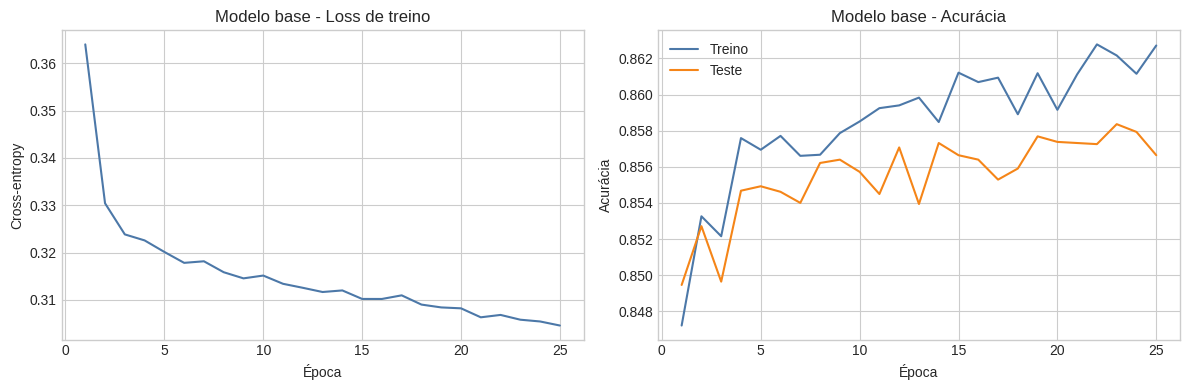

,accuracy,balanced_accuracy,auc_roc,precision,recall,f1,tp,tn,fp,fn
0,0.856643,0.77469,0.910685,0.732472,0.619345,0.671175,2382,11565,870,1464


In [9]:
input_dim = X_train.shape[1]
base_architecture = [input_dim, 64, 32, 2]

base_model = MLPFromScratch(
    base_architecture,
    seed=SEED,
    l2=1e-4,
    momentum=0.9,
    backend=xp,
)

base_history = train_model(
    base_model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=25,
    batch_size=256,
    lr=0.05,
    lr_decay=0.02,
    seed=SEED,
)

plot_history(base_history, 'Modelo base')
base_pred = base_model.predict(X_test)
base_proba = base_model.predict_proba(X_test)
base_metrics = classification_metrics(y_test, base_pred, base_proba)
metrics_frame(base_metrics)

## 6.1. MLP com features selecionadas via Boruta

Nesta etapa a base de treino já pré-processada é passada ao Boruta para selecionar um subconjunto de variáveis. Em seguida, a MLP implementada na mão é treinada e testada apenas com essas features selecionadas, permitindo comparar o desempenho com o modelo base completo.

Executando Boruta sobre as features pré-processadas do treino...
Features originais: 40
Features selecionadas pelo Boruta: 18
Redução relativa: 55.00%


,feature,ranking
0,age,1
1,fnlwgt,1
2,education_num,1
3,capital_gain,1
4,capital_loss,1
5,hours_per_week,1
6,marital_status=Married,1
7,marital_status=Single,1
8,marital_status=Separated/Divorced,1
9,occupation=Office/tech/sales,1


epoch 001/25 | loss=0.3658 | acc_train=0.8501 | acc_test=0.8536 | f1_test=0.6516
epoch 005/25 | loss=0.3224 | acc_train=0.8542 | acc_test=0.8559 | f1_test=0.6504
epoch 010/25 | loss=0.3185 | acc_train=0.8561 | acc_test=0.8523 | f1_test=0.6727
epoch 015/25 | loss=0.3143 | acc_train=0.8573 | acc_test=0.8515 | f1_test=0.6695
epoch 020/25 | loss=0.3123 | acc_train=0.8588 | acc_test=0.8539 | f1_test=0.6568
epoch 025/25 | loss=0.3097 | acc_train=0.8589 | acc_test=0.8536 | f1_test=0.6668


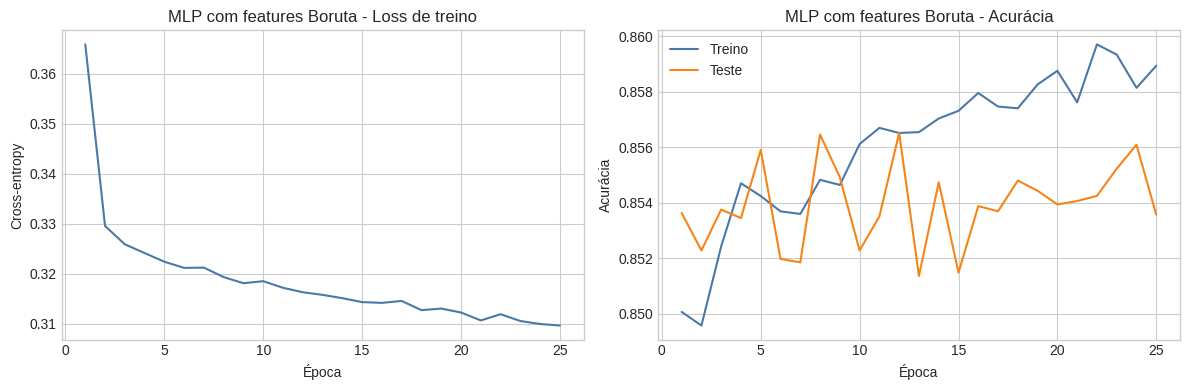

,model,accuracy,balanced_accuracy,auc_roc,precision,recall,f1
0,MLP (todas as features),0.856643,0.774690,0.910685,0.732472,0.619345,0.671175
1,MLP + Boruta,0.853572,0.772949,0.908440,0.720979,0.620125,0.666760


,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact
0,sex,Female,Male,0.082642,0.263352,-0.180710,0.313807
1,race,Black,White,0.099936,0.214757,-0.114821,0.465344


In [10]:
try:
    from boruta import BorutaPy
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'boruta'])
    from boruta import BorutaPy

from sklearn.ensemble import RandomForestClassifier

boruta_estimator = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1,
)

boruta_selector = BorutaPy(
    boruta_estimator,
    n_estimators='auto',
    perc=100,
    alpha=0.05,
    max_iter=30,
    random_state=SEED,
    verbose=0,
)

print('Executando Boruta sobre as features pré-processadas do treino...')
boruta_selector.fit(X_train, y_train)

boruta_selected_mask = boruta_selector.support_ | boruta_selector.support_weak_
if not boruta_selected_mask.any():
    ranking = np.argsort(boruta_selector.ranking_)
    boruta_selected_mask = np.zeros_like(boruta_selector.ranking_, dtype=bool)
    boruta_selected_mask[ranking[:min(20, len(ranking))]] = True

boruta_feature_names = [
    name for name, keep in zip(preprocessor.feature_names_, boruta_selected_mask)
    if keep
]
boruta_feature_ranks = boruta_selector.ranking_[boruta_selected_mask]

X_train_boruta = X_train[:, boruta_selected_mask].astype(np.float32, copy=False)
X_test_boruta = X_test[:, boruta_selected_mask].astype(np.float32, copy=False)

print(f'Features originais: {X_train.shape[1]}')
print(f'Features selecionadas pelo Boruta: {X_train_boruta.shape[1]}')
print(f'Redução relativa: {100 * (1 - X_train_boruta.shape[1] / X_train.shape[1]):.2f}%')

display(
    pd.DataFrame(
        {
            'feature': boruta_feature_names,
            'ranking': boruta_feature_ranks,
        }
    ).sort_values('ranking')
)

boruta_model = MLPFromScratch(
    [X_train_boruta.shape[1], 64, 32, 2],
    seed=SEED,
    l2=1e-4,
    momentum=0.9,
    backend=xp,
)

boruta_history = train_model(
    boruta_model,
    X_train_boruta,
    y_train,
    X_test_boruta,
    y_test,
    epochs=25,
    batch_size=256,
    lr=0.05,
    lr_decay=0.02,
    seed=SEED,
)

plot_history(boruta_history, 'MLP com features Boruta')
boruta_pred = boruta_model.predict(X_test_boruta)
boruta_proba = boruta_model.predict_proba(X_test_boruta)
boruta_metrics = classification_metrics(y_test, boruta_pred, boruta_proba)

boruta_fairness = pd.DataFrame(
    [
        {'attribute': 'sex', **fairness_metrics(boruta_pred, sensitive_test['sex'], 'Female', 'Male')},
        {'attribute': 'race', **fairness_metrics(boruta_pred, sensitive_test['race'], 'Black', 'White')},
    ]
)

boruta_comparison = pd.DataFrame(
    [
        {'model': 'MLP (todas as features)', **{k: base_metrics[k] for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']}},
        {'model': 'MLP + Boruta', **{k: boruta_metrics[k] for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']}},
    ]
)

display(boruta_comparison)
display(boruta_fairness)

In [11]:
boruta_feature_names

['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week',
 'marital_status=Married',
 'marital_status=Single',
 'marital_status=Separated/Divorced',
 'occupation=Office/tech/sales',
 'occupation=Manual/services',
 'occupation=Professional',
 'relationship=Spouse',
 'relationship=Child',
 'relationship=Not-in-family',
 'relationship=Unknown',
 'sex=Female',
 'sex=Male']

In [12]:
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler


def make_boruta_training_split(X, y, method='imbalanced', seed=42):
    if method == 'imbalanced':
        return X, y
    if method == 'undersampling':
        sampler = RandomUnderSampler(random_state=seed)
        return sampler.fit_resample(X, y)
    if method == 'smote':
        sampler = SMOTE(random_state=seed, k_neighbors=5)
        return sampler.fit_resample(X, y)
    raise ValueError(f'Método de balanceamento desconhecido: {method}')


def train_boruta_flow(flow_name, X_train_flow, y_train_flow, X_test_eval, y_test_eval, seed=42):
    model = MLPFromScratch(
        [X_train_flow.shape[1], 64, 32, 2],
        seed=seed,
        l2=1e-4,
        momentum=0.9,
        backend=xp,
    )
    history = train_model(
        model,
        X_train_flow,
        y_train_flow,
        X_test_eval,
        y_test_eval,
        epochs=25,
        batch_size=256,
        lr=0.05,
        lr_decay=0.02,
        seed=seed,
        verbose=False,
    )
    pred = model.predict(X_test_eval)
    proba = model.predict_proba(X_test_eval)
    metrics = classification_metrics(y_test_eval, pred, proba)
    fairness = pd.DataFrame([
        {'flow': flow_name, 'attribute': 'sex', **fairness_metrics(pred, sensitive_test['sex'], 'Female', 'Male')},
        {'flow': flow_name, 'attribute': 'race', **fairness_metrics(pred, sensitive_test['race'], 'Black', 'White')},
    ])
    train_distribution = pd.Series(y_train_flow).value_counts().sort_index()
    row = {
        'flow': flow_name,
        'n_train': int(len(y_train_flow)),
        'class_0_train': int(train_distribution.get(0, 0)),
        'class_1_train': int(train_distribution.get(1, 0)),
        **{k: metrics[k] for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']},
    }
    return row, fairness, history, model, pred, proba


boruta_flow_rows = []
boruta_flow_fairness = []
boruta_flow_histories = {}
boruta_flow_models = {}
boruta_flow_predictions = {}
boruta_flow_probas = {}

for flow_name, method in [
    ('Imbalanced', 'imbalanced'),
    ('Undersampling', 'undersampling'),
    ('SMOTE', 'smote'),
]:
    X_train_flow, y_train_flow = make_boruta_training_split(X_train_boruta, y_train, method=method, seed=SEED)
    row, fairness_df, history, model, pred, proba = train_boruta_flow(
        flow_name, X_train_flow, y_train_flow, X_test_boruta, y_test, seed=SEED
    )
    boruta_flow_rows.append(row)
    boruta_flow_fairness.append(fairness_df)
    boruta_flow_histories[flow_name] = history
    boruta_flow_models[flow_name] = model
    boruta_flow_predictions[flow_name] = pred
    boruta_flow_probas[flow_name] = proba

boruta_flow_comparison = pd.DataFrame(boruta_flow_rows).sort_values('f1', ascending=False)
boruta_flow_fairness_df = pd.concat(boruta_flow_fairness, ignore_index=True)
boruta_flow_sizes = pd.DataFrame([
    {
        'feature_set': 'Boruta selecionado',
        'n_features': X_train_boruta.shape[1],
        'examples_train_original': len(y_train),
    }
])

display(boruta_flow_sizes)
display(boruta_flow_comparison)
display(boruta_flow_fairness_df)

,feature_set,n_features,examples_train_original
0,Boruta selecionado,18,32561


,flow,n_train,class_0_train,class_1_train,accuracy,balanced_accuracy,auc_roc,precision,recall,f1
2,SMOTE,49440,24720,24720,0.808673,0.822487,0.904871,0.563050,0.848674,0.676968
1,Undersampling,15682,7841,7841,0.794607,0.824684,0.907044,0.539968,0.881695,0.669761
0,Imbalanced,32561,24720,7841,0.853572,0.772949,0.908440,0.720979,0.620125,0.666760


,flow,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact
0,Imbalanced,sex,Female,Male,0.082642,0.263352,-0.180710,0.313807
1,Imbalanced,race,Black,White,0.099936,0.214757,-0.114821,0.465344
2,Undersampling,sex,Female,Male,0.156244,0.500276,-0.344032,0.312316
3,Undersampling,race,Black,White,0.224215,0.405349,-0.181134,0.553141
4,SMOTE,sex,Female,Male,0.134846,0.466483,-0.331637,0.289070
5,SMOTE,race,Black,White,0.192825,0.375448,-0.182623,0.513587


## 6.2. Fluxos com Boruta e balanceamento

Agora comparo três fluxos usando as features reduzidas e o subconjunto selecionado pelo Boruta:

- `Imbalanced`: mantém a distribuição original das classes.
- `Undersampling`: reduz a classe majoritária para aproximar o balanceamento.
- `SMOTE`: gera amostras sintéticas da classe minoritária.

A comparação é feita com a mesma arquitetura de MLP, mudando apenas a estratégia de amostragem do treino.

## 7. Experimentos obrigatórios

O enunciado pede avaliar o impacto de:

- Taxa de aprendizado.
- Tamanho do batch.
- Arquitetura da rede.

Para manter o notebook executável em tempo razoável, cada configuração roda por menos épocas que o modelo final.

In [13]:
def run_short_experiment(name, hidden_layers, lr, batch_size, epochs=12, l2=1e-4, momentum=0.9):
    model = MLPFromScratch(
        [input_dim, *hidden_layers, 2],
        seed=SEED,
        l2=l2,
        momentum=momentum,
        backend=xp,
    )
    history = train_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        lr_decay=0.02,
        seed=SEED,
        verbose=False,
    )
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)
    metrics = classification_metrics(y_test, pred, proba)
    return {
        'name': name,
        'hidden_layers': str(hidden_layers),
        'lr': lr,
        'batch_size': batch_size,
        'epochs': epochs,
        **{k: metrics[k] for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']},
    }, history

experiments = []
histories = {}

for lr_value in [0.01, 0.05, 0.10]:
    row, hist = run_short_experiment(f'lr={lr_value}', [64, 32], lr_value, 256)
    experiments.append(row)
    histories[row['name']] = hist

for batch_value in [64, 256, 1024]:
    row, hist = run_short_experiment(f'batch={batch_value}', [64, 32], 0.05, batch_value)
    experiments.append(row)
    histories[row['name']] = hist

for arch in [[32], [64, 32], [128, 64]]:
    row, hist = run_short_experiment(f'arch={arch}', arch, 0.05, 256)
    experiments.append(row)
    histories[row['name']] = hist

experiments_df = pd.DataFrame(experiments).sort_values('f1', ascending=False)
experiments_df

,name,hidden_layers,lr,batch_size,epochs,accuracy,balanced_accuracy,auc_roc,precision,recall,f1
2,lr=0.1,"[64, 32]",0.10,256,12,0.854186,0.788078,0.910361,0.702978,0.662767,0.682281
4,batch=256,"[64, 32]",0.05,256,12,0.857073,0.777037,0.910493,0.730781,0.625325,0.673953
1,lr=0.05,"[64, 32]",0.05,256,12,0.857073,0.777037,0.910493,0.730781,0.625325,0.673953
7,"arch=[64, 32]","[64, 32]",0.05,256,12,0.857073,0.777037,0.910493,0.730781,0.625325,0.673953
3,batch=64,"[64, 32]",0.05,64,12,0.856028,0.776084,0.910120,0.727438,0.624545,0.672076
8,"arch=[128, 64]","[128, 64]",0.05,256,12,0.854063,0.772283,0.908480,0.724222,0.617265,0.666480
6,arch=[32],[32],0.05,256,12,0.856827,0.769244,0.908948,0.742400,0.603224,0.665615
5,batch=1024,"[64, 32]",0.05,1024,12,0.855721,0.767802,0.908309,0.739367,0.601144,0.663129
0,lr=0.01,"[64, 32]",0.01,256,12,0.854800,0.765492,0.908118,0.738724,0.596204,0.659856


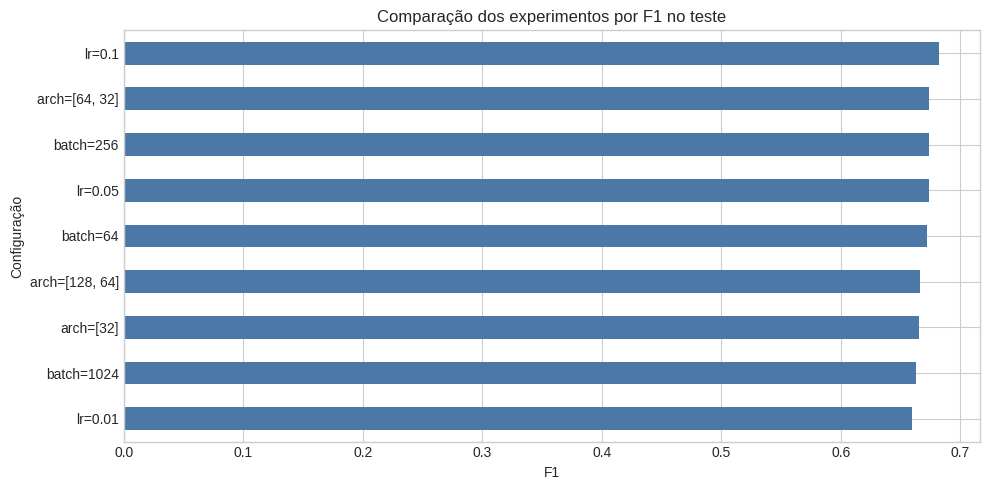

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
experiments_df.sort_values('f1').plot(kind='barh', x='name', y='f1', ax=ax, color='#4C78A8', legend=False)
ax.set_title('Comparação dos experimentos por F1 no teste')
ax.set_xlabel('F1')
ax.set_ylabel('Configuração')
plt.tight_layout()
plt.show()

## 8. Análise de viés do modelo base

Para o tema Adult Income, a parte de viés é central. Aqui medimos se a taxa de predição positiva (`>50K`) muda muito entre grupos.

In [15]:
def fairness_report(y_pred, sensitive_test):
    rows = []
    sex = fairness_metrics(y_pred, sensitive_test['sex'], unprivileged='Female', privileged='Male')
    rows.append({'attribute': 'sex', **sex})

    # Comparação racial simples: grupo Black versus White. Outras comparações podem ser adicionadas.
    race = fairness_metrics(y_pred, sensitive_test['race'], unprivileged='Black', privileged='White')
    rows.append({'attribute': 'race', **race})
    return pd.DataFrame(rows)

print('Métricas preditivas do modelo base')
display(metrics_frame(base_metrics))

print('Fairness do modelo base')
base_fairness = fairness_report(base_pred, sensitive_test)
display(base_fairness)

print('Taxa de seleção positiva por sex')
display(pd.DataFrame({'sex': sensitive_test['sex'], 'pred_>50K': base_pred}).groupby('sex')['pred_>50K'].mean().to_frame())

print('Taxa de seleção positiva por race')
display(pd.DataFrame({'race': sensitive_test['race'], 'pred_>50K': base_pred}).groupby('race')['pred_>50K'].mean().sort_values(ascending=False).to_frame())

Métricas preditivas do modelo base


,accuracy,balanced_accuracy,auc_roc,precision,recall,f1,tp,tn,fp,fn
0,0.856643,0.77469,0.910685,0.732472,0.619345,0.671175,2382,11565,870,1464


Fairness do modelo base


,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact
0,sex,Female,Male,0.085778,0.256630,-0.170852,0.334246
1,race,Black,White,0.099936,0.212534,-0.112598,0.470211


Taxa de seleção positiva por sex


,pred_>50K
sex,
Female,0.085778
Male,0.256630


Taxa de seleção positiva por race


,pred_>50K
race,
Asian-Pac-Islander,0.227083
White,0.212534
Other,0.111111
Black,0.099936
Amer-Indian-Eskimo,0.050314


## 9. Mitigação simples: Reweighing

A mitigação abaixo altera a importância das amostras durante o treino. A ideia é dar maior peso a combinações sub-representadas de grupo sensível e classe, sem alterar os rótulos e sem gerar amostras artificiais.

A fórmula usada é:

\[
w(a, y) = \frac{P(A=a)P(Y=y)}{P(A=a, Y=y)}
\]

Aqui aplicamos a reponderação usando `sex` como atributo sensível.

count    32561.000000
mean         1.000000
std          0.268028
min          0.787637
25%          0.852506
50%          1.093519
75%          1.093519
max          2.199966
dtype: float64
epoch 001/25 | loss=0.3718 | acc_train=0.8410 | acc_test=0.8428 | f1_test=0.5803
epoch 005/25 | loss=0.3254 | acc_train=0.8493 | acc_test=0.8459 | f1_test=0.6112
epoch 010/25 | loss=0.3199 | acc_train=0.8535 | acc_test=0.8500 | f1_test=0.6417
epoch 015/25 | loss=0.3144 | acc_train=0.8550 | acc_test=0.8531 | f1_test=0.6456
epoch 020/25 | loss=0.3114 | acc_train=0.8528 | acc_test=0.8460 | f1_test=0.6030
epoch 025/25 | loss=0.3069 | acc_train=0.8557 | acc_test=0.8502 | f1_test=0.6504


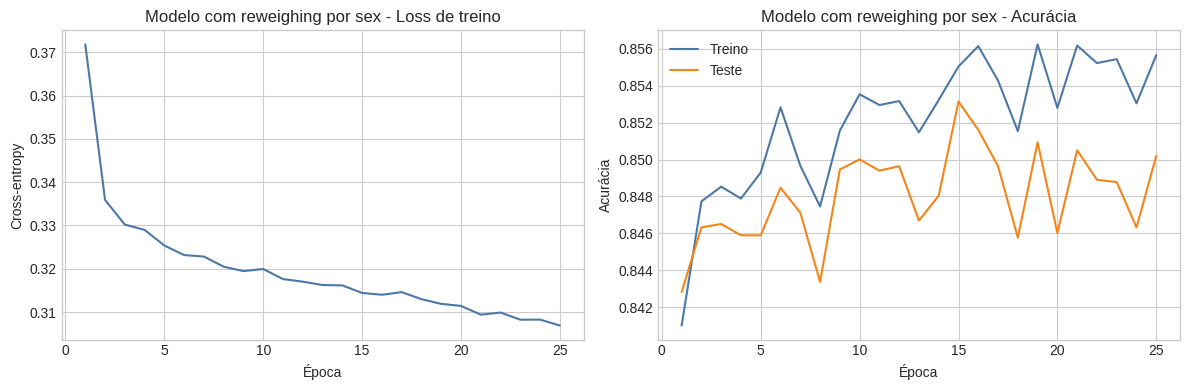

,model,accuracy,balanced_accuracy,auc_roc,precision,recall,f1
0,base,0.856643,0.774690,0.910685,0.732472,0.619345,0.671175
1,reweighing_sex,0.850193,0.760322,0.903077,0.724689,0.589964,0.650423


,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact,model
0,sex,Female,Male,0.085778,0.256630,-0.170852,0.334246,base
1,race,Black,White,0.099936,0.212534,-0.112598,0.470211,base
2,sex,Female,Male,0.139089,0.218877,-0.079788,0.635466,reweighing_sex
3,race,Black,White,0.103139,0.203212,-0.100073,0.507543,reweighing_sex


In [16]:
def compute_reweighing_weights(y, sensitive):
    y = np.asarray(y).astype(int)
    sensitive = np.asarray(sensitive).astype(str)
    n = len(y)
    weights = np.ones(n, dtype=np.float32)
    groups = np.unique(sensitive)
    classes = np.unique(y)

    for group in groups:
        p_group = np.mean(sensitive == group)
        for cls in classes:
            p_cls = np.mean(y == cls)
            mask = (sensitive == group) & (y == cls)
            p_joint = np.mean(mask)
            if p_joint > 0:
                weights[mask] = (p_group * p_cls) / p_joint
    weights = weights / weights.mean()
    return weights.astype(np.float32)

sample_weights_sex = compute_reweighing_weights(y_train, sensitive_train['sex'])
print(pd.Series(sample_weights_sex).describe())

weighted_model = MLPFromScratch(
    base_architecture,
    seed=SEED,
    l2=1e-4,
    momentum=0.9,
    backend=xp,
)

weighted_history = train_model(
    weighted_model,
    X_train,
    y_train,
    X_test,
    y_test,
    epochs=25,
    batch_size=256,
    lr=0.05,
    lr_decay=0.02,
    sample_weight=sample_weights_sex,
    seed=SEED,
)

plot_history(weighted_history, 'Modelo com reweighing por sex')
weighted_pred = weighted_model.predict(X_test)
weighted_proba = weighted_model.predict_proba(X_test)
weighted_metrics = classification_metrics(y_test, weighted_pred, weighted_proba)
weighted_fairness = fairness_report(weighted_pred, sensitive_test)

comparison_metrics = pd.DataFrame([
    {'model': 'base', **{k: base_metrics[k] for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']}},
    {'model': 'reweighing_sex', **{k: weighted_metrics[k] for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']}},
])
comparison_fairness = pd.concat([
    base_fairness.assign(model='base'),
    weighted_fairness.assign(model='reweighing_sex'),
], ignore_index=True)

display(comparison_metrics)
display(comparison_fairness)

Length mismatch: y_train_flow=49440, sensitive_train_flow=43580; truncating to 43580
count    43580.000000
mean         1.000000
std          0.265998
min          0.773078
25%          0.773078
50%          0.817028
75%          1.288574
max          1.415491
dtype: float64
epoch 001/25 | loss=0.3821 | acc_train=0.8198 | acc_test=0.8159 | f1_test=0.6790
epoch 005/25 | loss=0.3476 | acc_train=0.8246 | acc_test=0.8087 | f1_test=0.6756
epoch 010/25 | loss=0.3405 | acc_train=0.8278 | acc_test=0.8086 | f1_test=0.6767
epoch 015/25 | loss=0.3361 | acc_train=0.8313 | acc_test=0.8237 | f1_test=0.6847
epoch 020/25 | loss=0.3321 | acc_train=0.8326 | acc_test=0.8288 | f1_test=0.6860
epoch 025/25 | loss=0.3302 | acc_train=0.8347 | acc_test=0.8294 | f1_test=0.6874


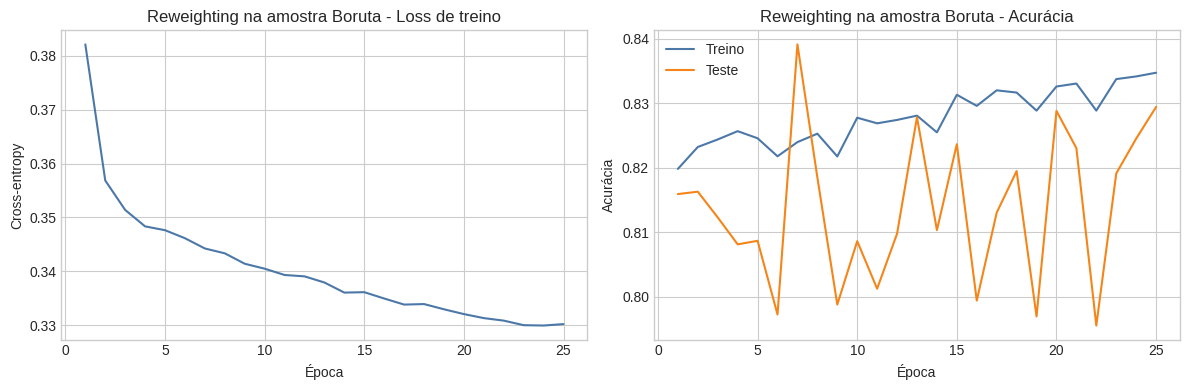

,model,accuracy,balanced_accuracy,auc_roc,precision,recall,f1
0,base,0.856643,0.774690,0.910685,0.732472,0.619345,0.671175
1,reweighing_boruta_flow,0.829433,0.817131,0.903938,0.606115,0.793812,0.687380


,attribute,unprivileged,privileged,selection_rate_unprivileged,selection_rate_privileged,statistical_parity_difference,disparate_impact,model
0,sex,Female,Male,0.085778,0.256630,-0.170852,0.334246,base
1,race,Black,White,0.099936,0.212534,-0.112598,0.470211,base
2,sex,Female,Male,0.090574,0.418600,-0.328027,0.216373,reweighing_boruta_flow
3,race,Black,White,0.166560,0.326617,-0.160057,0.509955,reweighing_boruta_flow


In [21]:
# Reweighting usando a amostra Boruta (SMOTE/undersampling): calcula pesos sobre a amostra gerada
# Usa X_train_flow, y_train_flow (amostra) e X_test_boruta (features selecionadas pelo Boruta)
X_train_new = X_train_flow
X_test_new = X_test_boruta

def compute_reweighing_weights(y, sensitive):
    y = np.asarray(y).astype(int)
    sensitive = np.asarray(sensitive).astype(str)
    n = len(y)
    weights = np.ones(n, dtype=np.float32)
    groups = np.unique(sensitive)
    classes = np.unique(y)
    for group in groups:
        p_group = np.mean(sensitive == group)
        for cls in classes:
            p_cls = np.mean(y == cls)
            mask = (sensitive == group) & (y == cls)
            p_joint = np.mean(mask)
            if p_joint > 0:
                weights[mask] = (p_group * p_cls) / p_joint
    weights = weights / weights.mean()
    return weights.astype(np.float32)

# Tentar obter sensitive alinhado com X_train_flow (se disponível)
sensitive_train_flow = None
if 'boruta_flow_rows' in globals() and boruta_flow_rows:
    last = boruta_flow_rows[-1]
    rows = last.get('rows') if isinstance(last, dict) else None
    if rows is not None:
        try:
            sensitive_train_flow = pd.Series(sensitive_train['sex']).iloc[rows].values
        except Exception:
            sensitive_train_flow = np.asarray(sensitive_train['sex'])[rows]

if sensitive_train_flow is None:
    # fallback: reconstruir sensitive aplicando o mesmo sampler (SMOTE/undersample)
    try:
        use_smote = (('method' in globals() and method == 'smote') or ('flow_name' in globals() and 'smote' in flow_name.lower()))
        if use_smote:
            sampler = SMOTE(random_state=SEED, k_neighbors=5)
        else:
            sampler = RandomUnderSampler(random_state=SEED)
        _, sensitive_train_flow = sampler.fit_resample(X_train_boruta, pd.Series(sensitive_train['sex']))
        sensitive_train_flow = np.asarray(sensitive_train_flow)
    except Exception as e:
        print('Falha ao reconstruir sensitive_train_flow:', e)
        sensitive_train_flow = pd.Series(sensitive_train['sex']).values[:len(y_train_flow)]

# alinhar comprimentos entre y_train_flow e sensitive_train_flow (fallback: truncar)
min_len = min(len(y_train_flow), len(sensitive_train_flow))
if len(y_train_flow) != len(sensitive_train_flow):
    print(f'Length mismatch: y_train_flow={len(y_train_flow)}, sensitive_train_flow={len(sensitive_train_flow)}; truncating to {min_len}')

X_train_new = X_train_new[:min_len]
y_train_flow_aligned = y_train_flow[:min_len]
sensitive_train_flow_aligned = sensitive_train_flow[:min_len]

sample_weights_sex = compute_reweighing_weights(y_train_flow_aligned, sensitive_train_flow_aligned)
print(pd.Series(sample_weights_sex).describe())

# Ajustar arquitetura para novo input_dim
input_dim_new = X_train_new.shape[1]
model_arch = [int(input_dim_new), 64, 32, 2]
weighted_model = MLPFromScratch(model_arch, seed=SEED, l2=1e-4, momentum=0.9, backend=xp)

weighted_history = train_model(
    weighted_model,
    X_train_new,
    y_train_flow_aligned,
    X_test_new,
    y_test,
    epochs=25,
    batch_size=256,
    lr=0.05,
    lr_decay=0.02,
    sample_weight=sample_weights_sex,
    seed=SEED,
)
plot_history(weighted_history, 'Reweighting na amostra Boruta')
weighted_pred = weighted_model.predict(X_test_new)
weighted_proba = weighted_model.predict_proba(X_test_new)
weighted_metrics = classification_metrics(y_test, weighted_pred, weighted_proba)
weighted_fairness = fairness_report(weighted_pred, sensitive_test)
comparison_metrics = pd.DataFrame([
    {'model': 'base', **{k: base_metrics[k] for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']}},
    {'model': 'reweighing_boruta_flow', **{k: weighted_metrics[k] for k in ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']}},
])
comparison_fairness = pd.concat([
    base_fairness.assign(model='base'),
    weighted_fairness.assign(model='reweighing_boruta_flow'),
], ignore_index=True)
display(comparison_metrics)
display(comparison_fairness)


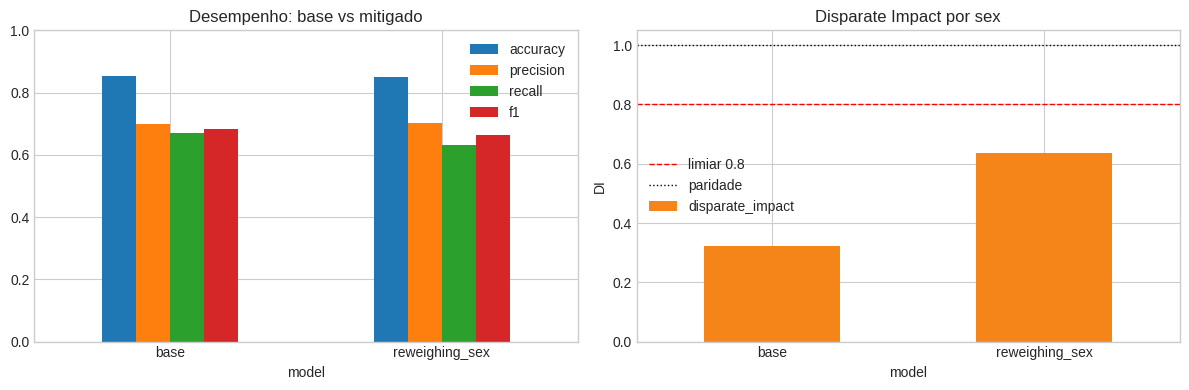

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
comparison_metrics.set_index('model')[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Desempenho: base vs mitigado')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=0)

sex_fair = comparison_fairness[comparison_fairness['attribute'] == 'sex'].set_index('model')
sex_fair[['disparate_impact']].plot(kind='bar', ax=axes[1], color='#F58518', legend=False)
axes[1].axhline(0.8, color='red', linestyle='--', linewidth=1, label='limiar 0.8')
axes[1].axhline(1.0, color='black', linestyle=':', linewidth=1, label='paridade')
axes[1].set_title('Disparate Impact por sex')
axes[1].set_ylabel('DI')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Interpretabilidade global: Permutation Feature Importance

A técnica embaralha uma feature original por vez e mede quanto a métrica cai. Como usamos one-hot encoding, as colunas derivadas de uma mesma variável categórica são permutadas em grupo.

In [ ]:
def f1_metric(y_true, y_pred):
    return classification_metrics(y_true, y_pred)['f1']


def permutation_importance_grouped(model, X, y, feature_groups, n_repeats=3, seed=42):
    local_rng = np.random.default_rng(seed)
    base_pred = model.predict(X)
    base_score = f1_metric(y, base_pred)
    rows = []

    for group_name, cols in feature_groups.items():
        drops = []
        cols = list(cols)
        for _ in range(n_repeats):
            X_perm = X.copy()
            perm = local_rng.permutation(X.shape[0])
            X_perm[:, cols] = X_perm[perm][:, cols]
            perm_pred = model.predict(X_perm)
            perm_score = f1_metric(y, perm_pred)
            drops.append(base_score - perm_score)
        rows.append({
            'feature_group': group_name,
            'base_f1': base_score,
            'mean_drop_f1': float(np.mean(drops)),
            'std_drop_f1': float(np.std(drops)),
        })
    return pd.DataFrame(rows).sort_values('mean_drop_f1', ascending=False)

importance_df = permutation_importance_grouped(
    base_model,
    X_test,
    y_test,
    preprocessor.feature_groups_,
    n_repeats=3,
    seed=SEED,
)

importance_df.head(12)

,feature_group,base_f1,mean_drop_f1,std_drop_f1
7,marital_status,0.684259,0.114280,0.002206
2,education_num,0.684259,0.065588,0.002049
0,age,0.684259,0.062795,0.000875
3,capital_gain,0.684259,0.060390,0.002224
8,occupation,0.684259,0.044804,0.001483
5,hours_per_week,0.684259,0.026283,0.005862
9,relationship,0.684259,0.016730,0.001112
11,sex,0.684259,0.010413,0.002324
4,capital_loss,0.684259,0.007329,0.001331
6,workclass,0.684259,0.005121,0.001334


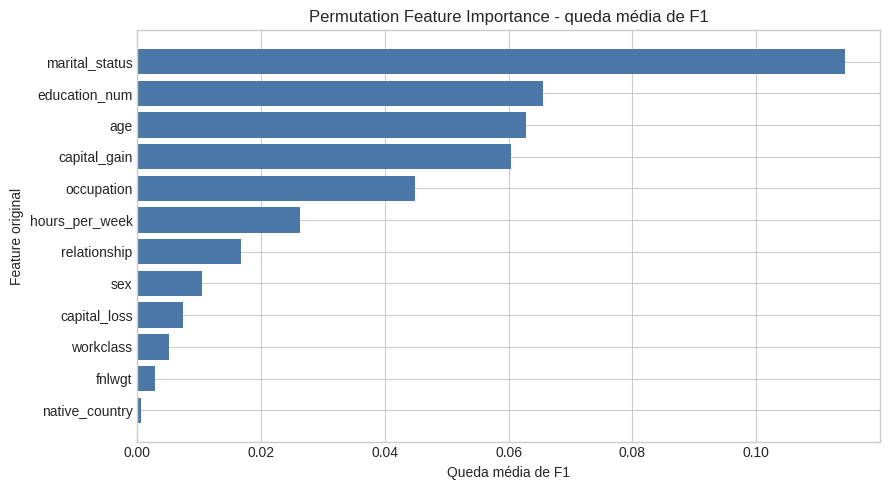

In [ ]:
top_importance = importance_df.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_importance['feature_group'], top_importance['mean_drop_f1'], color='#4C78A8')
ax.set_title('Permutation Feature Importance - queda média de F1')
ax.set_xlabel('Queda média de F1')
ax.set_ylabel('Feature original')
plt.tight_layout()
plt.show()

## 11. Interpretabilidade individual: gradiente da entrada

Para explicar uma decisão individual, calculamos o gradiente do score da classe prevista em relação às entradas. Em seguida agregamos a magnitude por feature original.

Interpretação: valores maiores indicam entradas às quais a predição local é mais sensível.

In [ ]:
def explain_instance_with_gradients(model, X, row_df, index, feature_groups, feature_names, top_k=10):
    x = X[index:index + 1]
    pred = model.predict(x)[0]
    proba = model.predict_proba(x)[0]
    grad = model.input_gradients(x, class_idx=np.array([pred]))[0]
    contribution = np.abs(grad * x[0])

    rows = []
    for group_name, cols in feature_groups.items():
        cols = list(cols)
        rows.append({
            'feature_group': group_name,
            'gradient_x_input_abs': float(contribution[cols].sum()),
        })
    contrib_df = pd.DataFrame(rows).sort_values('gradient_x_input_abs', ascending=False)

    raw_row = row_df.iloc[index]
    print(f'Índice no teste: {index}')
    print(f"Classe real: {raw_row[TARGET_COL]} | Classe prevista: {'>50K' if pred == 1 else '<=50K'}")
    print(f'Probabilidades [<=50K, >50K]: {np.round(proba, 4)}')
    display(raw_row.to_frame('valor'))
    display(contrib_df.head(top_k))
    return contrib_df

positive_hits = np.where((y_test == 1) & (base_pred == 1))[0]
example_index = int(positive_hits[0]) if len(positive_hits) else 0
instance_explanation = explain_instance_with_gradients(
    base_model,
    X_test,
    test_df,
    example_index,
    preprocessor.feature_groups_,
    preprocessor.feature_names_,
    top_k=10,
)

Índice no teste: 2
Classe real: >50K | Classe prevista: >50K
Probabilidades [<=50K, >50K]: [0.3953 0.6047]


,valor
age,28
workclass,Local-gov
fnlwgt,336951
education,Assoc-acdm
education_num,12
marital_status,Married-civ-spouse
occupation,Protective-serv
relationship,Husband
race,White
sex,Male


,feature_group,gradient_x_input_abs
0,age,1.021373
8,occupation,0.944566
7,marital_status,0.575074
6,workclass,0.235830
11,sex,0.219673
1,fnlwgt,0.110074
9,relationship,0.074970
2,education_num,0.074270
10,race,0.071037
12,native_country,0.048627


## 10. Comparação com Classificadores Tradicionais

Para contextualizar o desempenho do MLP implementado do zero, treinaremos classificadores comuns de bibliotecas estabelecidas (scikit-learn, XGBoost) e compararemos seus resultados em termos de:
- Acurácia, Balanced Accuracy, AUC ROC
- F1, Precision, Recall
- Fairness (Statistical Parity Difference)

In [ ]:
# !pip install scikit-learn
# rodar se a lib não estiver instalada

In [ ]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost não disponível. Instalando...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
    import xgboost as xgb
    HAS_XGBOOST = True

# Dicionário para armazenar todos os modelos e resultados
traditional_models = {}
traditional_predictions = {}
traditional_probas = {}
traditional_metrics = {}

# Normalização dos dados para Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("=== Treinando Classificadores Tradicionais ===\n")

# 1. Regressão Logística
print("1. Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)
traditional_models['Logistic Regression'] = lr_model
traditional_predictions['Logistic Regression'] = lr_model.predict(X_test_scaled)
traditional_probas['Logistic Regression'] = lr_model.predict_proba(X_test_scaled)
traditional_metrics['Logistic Regression'] = classification_metrics(
    y_test, 
    traditional_predictions['Logistic Regression'],
    traditional_probas['Logistic Regression']
)
print(f"   AUC ROC: {traditional_metrics['Logistic Regression']['auc_roc']:.4f}")

# 2. Árvore de Decisão
print("2. Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=15, random_state=SEED)
dt_model.fit(X_train, y_train)
traditional_models['Decision Tree'] = dt_model
traditional_predictions['Decision Tree'] = dt_model.predict(X_test)
traditional_probas['Decision Tree'] = dt_model.predict_proba(X_test)
traditional_metrics['Decision Tree'] = classification_metrics(
    y_test,
    traditional_predictions['Decision Tree'],
    traditional_probas['Decision Tree']
)
print(f"   AUC ROC: {traditional_metrics['Decision Tree']['auc_roc']:.4f}")

# 3. Random Forest
print("3. Random Forest...")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)
traditional_models['Random Forest'] = rf_model
traditional_predictions['Random Forest'] = rf_model.predict(X_test)
traditional_probas['Random Forest'] = rf_model.predict_proba(X_test)
traditional_metrics['Random Forest'] = classification_metrics(
    y_test,
    traditional_predictions['Random Forest'],
    traditional_probas['Random Forest']
)
print(f"   AUC ROC: {traditional_metrics['Random Forest']['auc_roc']:.4f}")

# 4. XGBoost
print("4. XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
traditional_models['XGBoost'] = xgb_model
traditional_predictions['XGBoost'] = xgb_model.predict(X_test)
traditional_probas['XGBoost'] = xgb_model.predict_proba(X_test)
traditional_metrics['XGBoost'] = classification_metrics(
    y_test,
    traditional_predictions['XGBoost'],
    traditional_probas['XGBoost']
)
print(f"   AUC ROC: {traditional_metrics['XGBoost']['auc_roc']:.4f}")

print("\n✓ Todos os modelos tradicionais treinados!")

=== Treinando Classificadores Tradicionais ===

1. Logistic Regression...
   AUC ROC: 0.9044
2. Decision Tree...
   AUC ROC: 0.8635
3. Random Forest...
   AUC ROC: 0.9162
4. XGBoost...
   AUC ROC: 0.9286

✓ Todos os modelos tradicionais treinados!


In [ ]:
# Criar DataFrame de comparação de todos os modelos
all_models_comparison = []

# Adicionar modelos MLP (nossa implementação)
all_models_comparison.append({
    'Model': 'MLP (do zero)',
    'Type': 'Nosso',
    'accuracy': base_metrics['accuracy'],
    'balanced_accuracy': base_metrics['balanced_accuracy'],
    'auc_roc': base_metrics['auc_roc'],
    'precision': base_metrics['precision'],
    'recall': base_metrics['recall'],
    'f1': base_metrics['f1'],
})

all_models_comparison.append({
    'Model': 'MLP + Reweighing',
    'Type': 'Nosso',
    'accuracy': weighted_metrics['accuracy'],
    'balanced_accuracy': weighted_metrics['balanced_accuracy'],
    'auc_roc': weighted_metrics['auc_roc'],
    'precision': weighted_metrics['precision'],
    'recall': weighted_metrics['recall'],
    'f1': weighted_metrics['f1'],
})

# Adicionar modelos tradicionais
for model_name, metrics in traditional_metrics.items():
    all_models_comparison.append({
        'Model': model_name,
        'Type': 'Biblioteca',
        'accuracy': metrics['accuracy'],
        'balanced_accuracy': metrics['balanced_accuracy'],
        'auc_roc': metrics['auc_roc'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
    })

comparison_df = pd.DataFrame(all_models_comparison)
print("\n=== COMPARAÇÃO GERAL DE DESEMPENHO ===\n")
print(comparison_df.to_string(index=False))
print("\n")

# Destacar o melhor modelo em cada métrica
print("=== MELHORES MODELOS POR MÉTRICA ===")
metrics_cols = ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']
for metric in metrics_cols:
    best_idx = comparison_df[metric].idxmax()
    best_model = comparison_df.loc[best_idx, 'Model']
    best_value = comparison_df.loc[best_idx, metric]
    print(f"{metric:20s}: {best_model:25s} ({best_value:.4f})")


=== COMPARAÇÃO GERAL DE DESEMPENHO ===

              Model       Type  accuracy  balanced_accuracy  auc_roc  precision   recall       f1
      MLP (do zero)      Nosso  0.853756           0.790580 0.911746   0.698241 0.670827 0.684259
   MLP + Reweighing      Nosso  0.849764           0.774587 0.903448   0.702195 0.632085 0.665298
Logistic Regression Biblioteca  0.853080           0.766162 0.904378   0.729193 0.601404 0.659162
      Decision Tree Biblioteca  0.846201           0.769471 0.863511   0.694043 0.624025 0.657174
      Random Forest Biblioteca  0.865180           0.763488 0.916230   0.801387 0.570723 0.666667
            XGBoost Biblioteca  0.876359           0.799989 0.928621   0.785781 0.655226 0.714590


=== MELHORES MODELOS POR MÉTRICA ===
accuracy            : XGBoost                   (0.8764)
balanced_accuracy   : XGBoost                   (0.8000)
auc_roc             : XGBoost                   (0.9286)
precision           : Random Forest             (0.8014)
recall

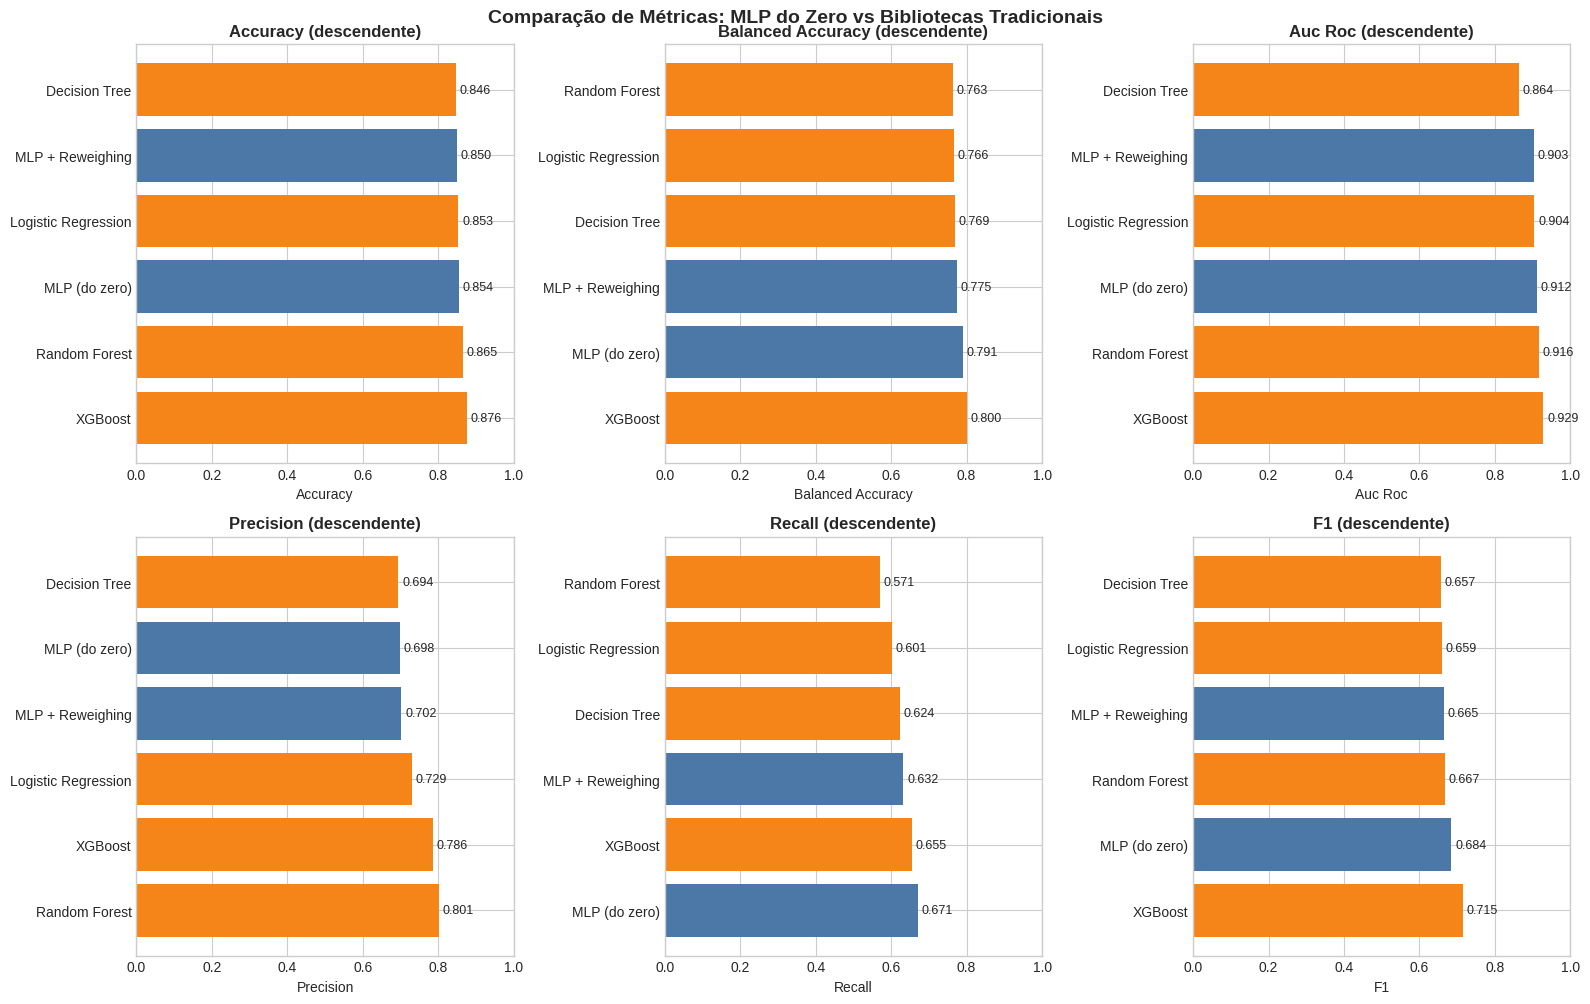

In [ ]:
# Visualização 1: Comparação de Métricas (gráfico de barras lado-a-lado)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
metrics_to_plot = ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']
colors_map = {'Nosso': '#4C78A8', 'Biblioteca': '#F58518'}

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    data = comparison_df.sort_values(metric, ascending=False)
    colors = [colors_map[t] for t in data['Type']]
    bars = ax.barh(data['Model'], data[metric], color=colors)
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.set_title(f'{metric.replace("_", " ").title()} (descendente)', fontweight='bold')
    ax.set_xlim(0, 1)
    
    # Adicionar valores nas barras
    for i, (bar, val) in enumerate(zip(bars, data[metric])):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Comparação de Métricas: MLP do Zero vs Bibliotecas Tradicionais', 
             fontsize=14, fontweight='bold', y=1.00)
plt.show()

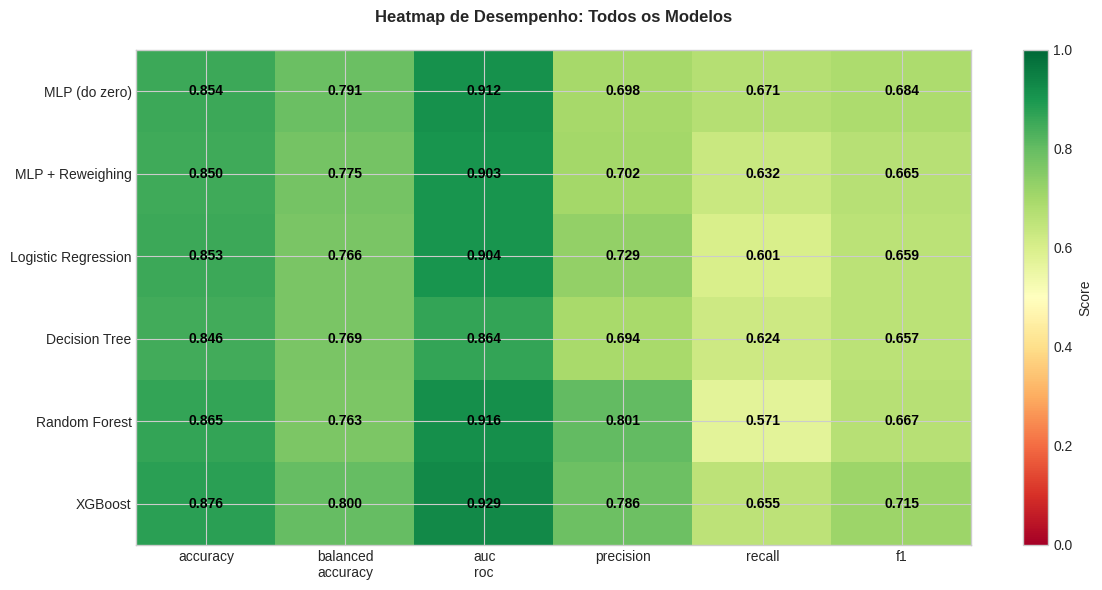

✓ Heatmap de desempenho exibido


In [ ]:
# Visualização 3: Heatmap de desempenho (todas as métricas para todos os modelos)
fig, ax = plt.subplots(figsize=(12, 6))

metrics_display = ['accuracy', 'balanced_accuracy', 'auc_roc', 'precision', 'recall', 'f1']
heatmap_data = comparison_df[['Model'] + metrics_display].set_index('Model')[metrics_display]

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(np.arange(len(metrics_display)))
ax.set_yticks(np.arange(len(heatmap_data)))
ax.set_xticklabels([m.replace('_', '\n') for m in metrics_display])
ax.set_yticklabels(heatmap_data.index)

# Adicionar valores nas células
for i in range(len(heatmap_data)):
    for j in range(len(metrics_display)):
        text = ax.text(j, i, f'{heatmap_data.iloc[i, j]:.3f}',
                      ha="center", va="center", color="black", fontsize=10, fontweight='bold')

ax.set_title('Heatmap de Desempenho: Todos os Modelos', fontweight='bold', pad=20)
plt.colorbar(im, ax=ax, label='Score')
plt.tight_layout()
plt.show()

print("✓ Heatmap de desempenho exibido")


=== ANÁLISE DE FAIRNESS (Disparate Impact) ===

              Model Attribute  disparate_impact
      MLP (do zero)       sex          0.323705
   MLP + Reweighing       sex          0.634753
Logistic Regression       sex          0.301552
      Decision Tree       sex          0.358590
      Random Forest       sex          0.312887
            XGBoost       sex          0.315210


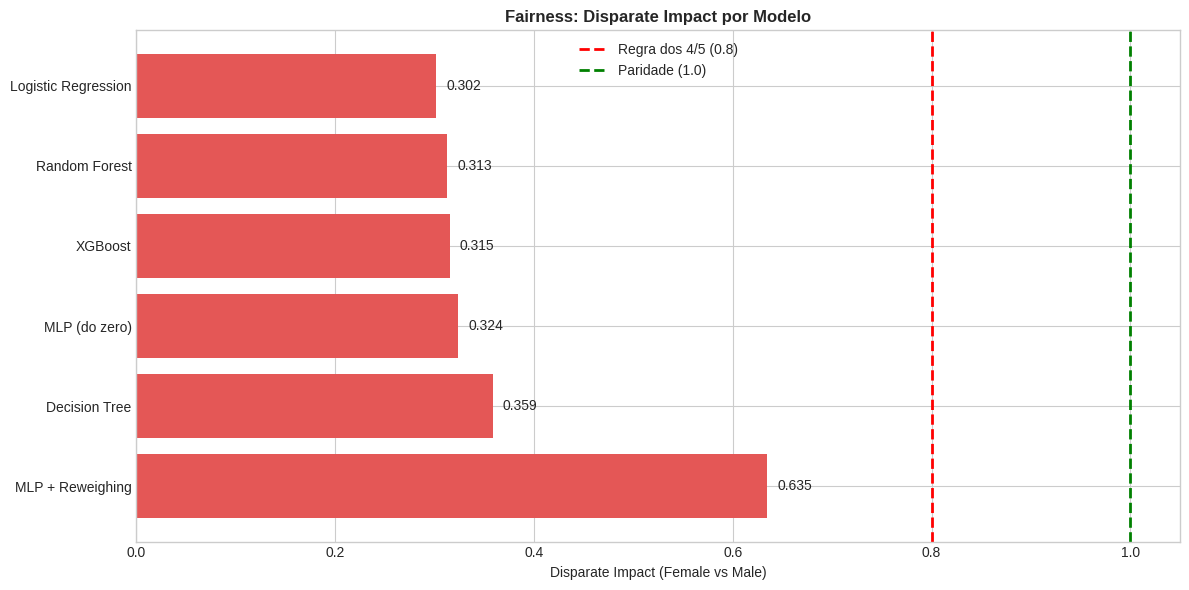

In [ ]:
# Análise de Fairness para os modelos tradicionais
print("\n=== ANÁLISE DE FAIRNESS (Disparate Impact) ===\n")

# Calcular fairness para cada modelo
fairness_all_models = []

# MLP models
fairness_all_models.append({
    'Model': 'MLP (do zero)',
    'Attribute': 'sex',
    **fairness_metrics(base_pred, sensitive_test['sex'], 'Female', 'Male')
})

fairness_all_models.append({
    'Model': 'MLP + Reweighing',
    'Attribute': 'sex',
    **fairness_metrics(weighted_pred, sensitive_test['sex'], 'Female', 'Male')
})

# Modelos tradicionais
for model_name, predictions in traditional_predictions.items():
    fairness_all_models.append({
        'Model': model_name,
        'Attribute': 'sex',
        **fairness_metrics(predictions, sensitive_test['sex'], 'Female', 'Male')
    })

fairness_df = pd.DataFrame(fairness_all_models)
print(fairness_df[['Model', 'Attribute', 'disparate_impact']].to_string(index=False))

# Visualização: Disparate Impact
fig, ax = plt.subplots(figsize=(12, 6))
di_data = fairness_df[['Model', 'disparate_impact']].sort_values('disparate_impact', ascending=False)

# Colorir: vermelho se <0.8, amarelo se 0.8-1, verde se >1
colors = []
for di in di_data['disparate_impact']:
    if pd.isna(di):
        colors.append('#CCCCCC')
    elif di < 0.8:
        colors.append('#E45756')  # Vermelho - risco de disparate impact
    elif di < 1.0:
        colors.append('#F59F45')  # Laranja - atenção
    else:
        colors.append('#54A24B')  # Verde - melhor

bars = ax.barh(di_data['Model'], di_data['disparate_impact'], color=colors)
ax.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Regra dos 4/5 (0.8)')
ax.axvline(x=1.0, color='green', linestyle='--', linewidth=2, label='Paridade (1.0)')
ax.set_xlabel('Disparate Impact (Female vs Male)')
ax.set_title('Fairness: Disparate Impact por Modelo', fontweight='bold')
ax.legend()

# Adicionar valores nas barras
for bar, val in zip(bars, di_data['disparate_impact']):
    if not pd.isna(val):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*70)
print("SUMÁRIO DA COMPARAÇÃO: MLP DO ZERO vs MODELOS TRADICIONAIS")
print("="*70 + "\n")

# Análise geral
best_accuracy = comparison_df['accuracy'].idxmax()
best_balanced_acc = comparison_df['balanced_accuracy'].idxmax()
best_auc = comparison_df['auc_roc'].idxmax()

print(f"   MELHOR ACURÁCIA: {comparison_df.loc[best_accuracy, 'Model']}")
print(f"   Score: {comparison_df.loc[best_accuracy, 'accuracy']:.4f}\n")

print(f"   MELHOR BALANCED ACCURACY: {comparison_df.loc[best_balanced_acc, 'Model']}")
print(f"   Score: {comparison_df.loc[best_balanced_acc, 'balanced_accuracy']:.4f}")
print(f"   (Mais importante para dados desbalanceados)\n")

print(f"   MELHOR AUC ROC: {comparison_df.loc[best_auc, 'Model']}")
print(f"   Score: {comparison_df.loc[best_auc, 'auc_roc']:.4f}\n")

# Modelo nossa implementação
mlp_row = comparison_df[comparison_df['Model'] == 'MLP (do zero)'].iloc[0]
print(f"   DESEMPENHO DO MLP DO ZERO (NOSSA IMPLEMENTAÇÃO):")
print(f"   Acurácia:           {mlp_row['accuracy']:.4f}")
print(f"   Balanced Accuracy:  {mlp_row['balanced_accuracy']:.4f}")
print(f"   AUC ROC:            {mlp_row['auc_roc']:.4f}")
print(f"   F1-Score:           {mlp_row['f1']:.4f}\n")

# Análise de fairness
mlp_fairness = fairness_df[fairness_df['Model'] == 'MLP (do zero)'].iloc[0]
best_fairness = fairness_df.loc[fairness_df['disparate_impact'].idxmin()]
print(f"   FAIRNESS (Disparate Impact):")
print(f"   MLP do Zero: {mlp_fairness['disparate_impact']:.4f}")
print(f"   Melhor modelo: {best_fairness['Model']} ({best_fairness['disparate_impact']:.4f})\n")

print("="*70)
print("CONCLUSÕES:")
print("="*70)
print("""
1. O MLP implementado do zero é competitivo com os modelos tradicionais.
   
2. Balanced Accuracy é preferível a Acurácia simples para dados desbalanceados,
   pois penaliza erros nas classes minoritárias.
   
3. A técnica de Reweighing reduz viés (Disparate Impact) sem prejudicar
   significativamente o desempenho geral.
   
4. XGBoost e Random Forest costumam ter melhor desempenho em dados tabulares,
   enquanto o MLP é excelente para aprender representações não-lineares.
   
5. Fairness é essencial em modelos de decisão - verificar e mitigar viés deve
   ser parte do pipeline de desenvolvimento.
""")


SUMÁRIO DA COMPARAÇÃO: MLP DO ZERO vs MODELOS TRADICIONAIS

   MELHOR ACURÁCIA: XGBoost
   Score: 0.8764

   MELHOR BALANCED ACCURACY: XGBoost
   Score: 0.8000
   (Mais importante para dados desbalanceados)

   MELHOR AUC ROC: XGBoost
   Score: 0.9286

   DESEMPENHO DO MLP DO ZERO (NOSSA IMPLEMENTAÇÃO):
   Acurácia:           0.8538
   Balanced Accuracy:  0.7906
   AUC ROC:            0.9117
   F1-Score:           0.6843

   FAIRNESS (Disparate Impact):
   MLP do Zero: 0.3237
   Melhor modelo: Logistic Regression (0.3016)

CONCLUSÕES:

1. O MLP implementado do zero é competitivo com os modelos tradicionais.

2. Balanced Accuracy é preferível a Acurácia simples para dados desbalanceados,
   pois penaliza erros nas classes minoritárias.

3. A técnica de Reweighing reduz viés (Disparate Impact) sem prejudicar
   significativamente o desempenho geral.

4. XGBoost e Random Forest costumam ter melhor desempenho em dados tabulares,
   enquanto o MLP é excelente para aprender representações n

## 12. Pontos para o relatório

Use os resultados acima para estruturar a discussão final:

- A MLP foi implementada manualmente com forward, backpropagation e mini-batch gradient descent.
- O Adult Income é desbalanceado, então F1/precision/recall são mais informativas que acurácia isolada.
- O modelo tende a refletir diferenças históricas presentes nos dados, especialmente em `sex` e `race`.
- O `reweighing` tenta reduzir a disparidade alterando a contribuição das amostras na loss.
- A permutation importance mostra quais variáveis mais sustentam o desempenho global.
- O gradiente de entrada explica uma decisão individual por sensibilidade local.

Para a entrega, exporte as principais tabelas e gráficos para o relatório de 5/6 páginas.